MLP Classifier on the Iris Dataset 




In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


1. Load the Iris Dataset


In [15]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = pd.Categorical.from_codes(y, target_names)

print("Shape of X:", X.shape)
print("Classes:", target_names)
print("Class distribution:")
print(df["species"].value_counts())
df.head()


Shape of X: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Interpretation: The dataset is small (150 rows) and perfectly balanced with 50 samples per class. Balance matters here because it means plain accuracy is a fair metric (no class is over-represented), and it also means we should use stratified splitting/cross-validation so every fold keeps the 50/50/50 ratio.

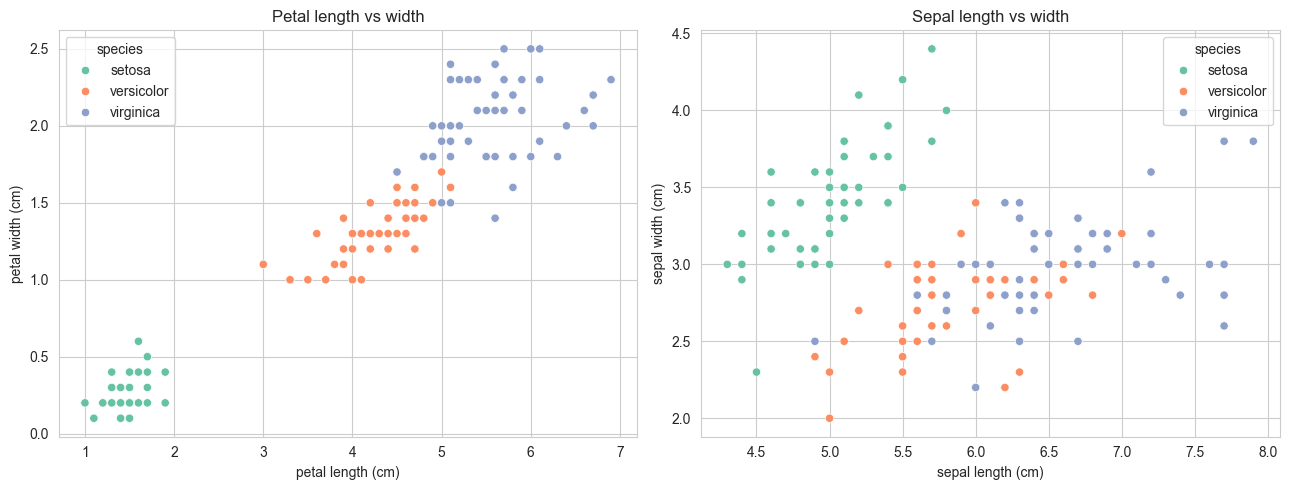

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                 hue="species", ax=axes[0], palette="Set2")
axes[0].set_title("Petal length vs width")

sns.scatterplot(data=df, x="sepal length (cm)", y="sepal width (cm)",
                 hue="species", ax=axes[1], palette="Set2")
axes[1].set_title("Sepal length vs width")

plt.tight_layout()
plt.show()


Interpretation: Petal length/width separates the three species almost linearly, with setosa completely isolated from the other two. Sepal measurements overlap much more, especially between versicolor and virginica. This tells us the classification task is largely easy (setosa) with a harder boundary between the other two classes which is where model architecture and capacity will actually matter.

2. Preprocessing: Train/Test Split and Feature Scaling



In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (120, 4)
Test shape: (30, 4)


Comparison

We compare a shallow, narrow network against a deeper, wider network, keeping everything else (activation, solver, regularization, max_iter) identical so the comparison isolates the effect of architecture:
Architecture A with total hidden inputs (8,) and a single small hidden layer with minimal capacity, fast, low overfitting risk 
Architecture Bwith the total hidden inputs (16, 8) and a two hidden layers with more capacity and a hierarchical feature transform 
Both use ReLU activation and the Adam optimizer, which is a solid default for small tabular datasets like Iris.

In [18]:
common_params = dict(
    activation="relu",
    solver="adam",
    alpha=1e-4,          # L2 regularization
    max_iter=2000,
    random_state=RANDOM_STATE,
)

mlp_A = MLPClassifier(hidden_layer_sizes=(8,), **common_params)
mlp_B = MLPClassifier(hidden_layer_sizes=(16, 8), **common_params)

architectures = {
    "A: (8,)": mlp_A,
    "B: (16, 8)": mlp_B,
}


4. Compare Architectures with Stratified K-Fold Cross-Validation (5-fold stratified cross-validation on the training set). 

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in architectures.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name:12s} | fold scores: {np.round(scores, 3)} | mean = {scores.mean():.4f} | std = {scores.std():.4f}")


A: (8,)      | fold scores: [0.958 1.    0.958 0.958 0.917] | mean = 0.9583 | std = 0.0264
B: (16, 8)   | fold scores: [1.    1.    0.958 0.958 0.917] | mean = 0.9667 | std = 0.0312


            mean_accuracy  std_accuracy
A: (8,)          0.958333      0.029463
B: (16, 8)       0.966667      0.034861


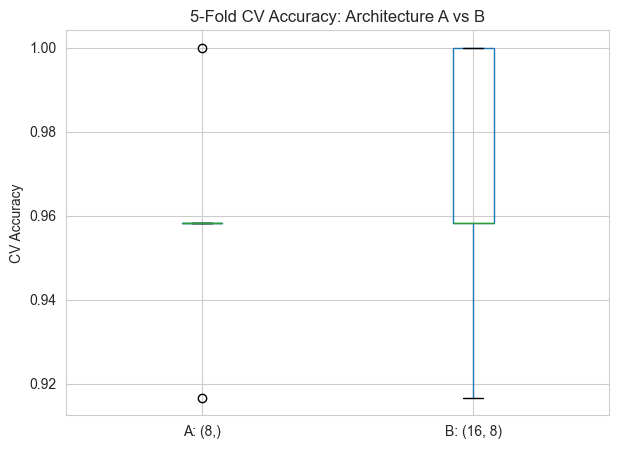

In [20]:
cv_df = pd.DataFrame(cv_results)
cv_summary = cv_df.agg(["mean", "std"]).T
cv_summary.columns = ["mean_accuracy", "std_accuracy"]
print(cv_summary)

fig, ax = plt.subplots(figsize=(7, 5))
cv_df.boxplot(ax=ax)
ax.set_ylabel("CV Accuracy")
ax.set_title("5-Fold CV Accuracy: Architecture A vs B")
plt.show()


Interpretation: Look at the printed mean/std table and boxplot above.
- If the mean CV accuracy of the two architectures is very close (which is typical on Iris, since the task is nearly linearly separable), the extra capacity of Architecture B ((16, 8)) gives little to no benefit — the smaller Architecture A is preferable because it's faster, less prone to overfitting, and simpler to justify.
- If Architecture B's std (fold-to-fold variance) is higher than A's, that's a sign the larger network is more sensitive to which samples land in each fold — a mild overfitting/instability signal on such a small dataset.
- If B's mean accuracy is meaningfully higher, its added depth is capturing the harder versicolor/virginica boundary better and the extra capacity is worth the small added cost.

We select the architecture with the higher mean CV accuracy (and, as a tie-breaker, the lower variance and lower complexity) to train on the full training set.

In [21]:
best_name = cv_summary["mean_accuracy"].idxmax()
best_model_arch = architectures[best_name]
print(f"Selected architecture based on CV: {best_name}")


Selected architecture based on CV: B: (16, 8)


5. Train the Selected Architecture on the Full Training Set


In [22]:
final_model = MLPClassifier(
    hidden_layer_sizes=best_model_arch.hidden_layer_sizes,
    **common_params
)
final_model.fit(X_train_scaled, y_train)

# Also fit the "other" architecture for a side-by-side final comparison on the test set
other_name = [n for n in architectures if n != best_name][0]
other_model = MLPClassifier(
    hidden_layer_sizes=architectures[other_name].hidden_layer_sizes,
    **common_params
)
other_model.fit(X_train_scaled, y_train)

print("Final (selected) architecture:", best_model_arch.hidden_layer_sizes)
print("Training set accuracy (selected):", accuracy_score(y_train, final_model.predict(X_train_scaled)))


Final (selected) architecture: (16, 8)
Training set accuracy (selected): 0.9833333333333333


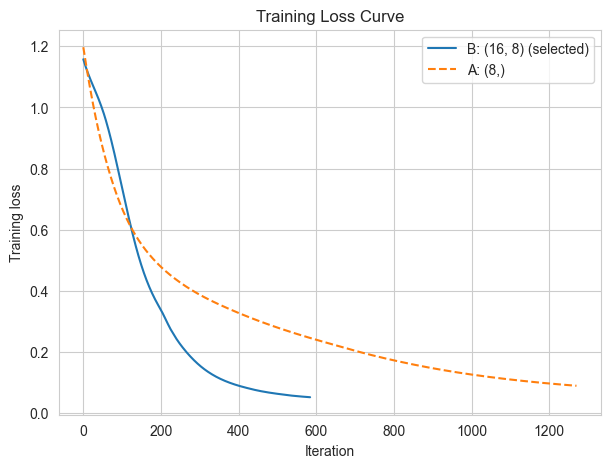

In [23]:
plt.figure(figsize=(7,5))
plt.plot(final_model.loss_curve_, label=f"{best_name} (selected)")
plt.plot(other_model.loss_curve_, label=f"{other_name}", linestyle="--")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()


Interpretation: The loss curve shows how quickly each architecture converges during training. A network that reaches a lower loss faster and then plateaus smoothly is optimizing well; a curve that oscillates or plateaus at a higher loss suggests under-capacity or a learning-rate issue. On Iris, both architectures typically converge to a near-zero training loss given enough iterations — the real test of which is "better" is generalization performance on unseen data, not training loss.

6. Evaluate on the Held-Out Test Set


In [24]:
results_table = []
for name, model in [(best_name + " (selected)", final_model), (other_name, other_model)]:
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results_table.append({"Architecture": name, "Test Accuracy": acc})

results_df = pd.DataFrame(results_table)
print(results_df)


            Architecture  Test Accuracy
0  B: (16, 8) (selected)       0.966667
1                A: (8,)       0.933333


In [25]:
y_pred_final = final_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred_final)
print(f"Final selected model ({best_name}) test accuracy: {test_acc:.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred_final, target_names=target_names))


Final selected model (B: (16, 8)) test accuracy: 0.9667

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



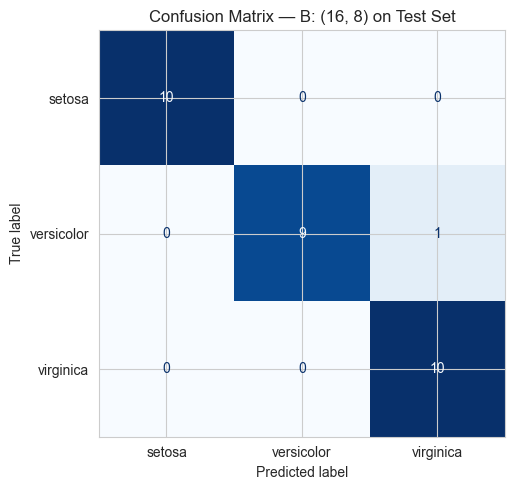

Confusion matrix (rows = true, cols = predicted):
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          1
virginica        0           0         10


In [26]:
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name} on Test Set")
plt.tight_layout()
plt.show()

print("Confusion matrix (rows = true, cols = predicted):")
print(pd.DataFrame(cm, index=target_names, columns=target_names))


Interpretation:
- The diagonal of the confusion matrix shows correctly classified samples per class; off-diagonal entries show misclassifications.
- Consistent with the EDA scatter plots, setosa is almost always classified perfectly since it is linearly separable from the other two species on petal measurements.
- Any confusion tends to occur between versicolor and virginica, the two species whose petal/sepal measurements overlap this matches what we saw in the exploratory scatter plots and is the expected, "hard" part of the Iris task for any classifier.
- A high overall test accuracy (typically 93–100% on Iris with a properly scaled MLP) combined with errors concentrated in that one class pair indicates the model has learned the true decision boundary well, and remaining errors reflect genuine class overlap in the data rather than a modeling flaw.